# Housing Bias

## Libraries

In [3]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

## Data

In [5]:
#Import data
df = pd.read_csv('data/mortgage_covenant_data.csv')

In [6]:
df.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [7]:
df.isnull().sum()

activity_year                            0
census_tract                          1016
derived_race                             0
action_taken                             0
loan_amount                              0
property_value                       17440
income                               12731
interest_rate                        22806
tract_minority_population_percent        0
tract_to_msa_income_percentage           0
denial_reason-1                          0
covenant_count                           0
was_approved                             0
covenant_density                     89762
dtype: int64

## Visualizations

In [9]:
df_pie1 = df.copy()

In [10]:
df_pie1 = df_pie1[df_pie1["derived_race"].str.contains("Race Not Available") == False]
df_pie1 = df_pie1[df_pie1["derived_race"].str.contains("Free Form Text Only") == False]
df_pie1['derived_race'].value_counts()

derived_race
White                                        63627
Asian                                         5905
Black or African American                     5199
Joint                                         2427
American Indian or Alaska Native               709
2 or more minority races                       135
Native Hawaiian or Other Pacific Islander      113
Name: count, dtype: int64

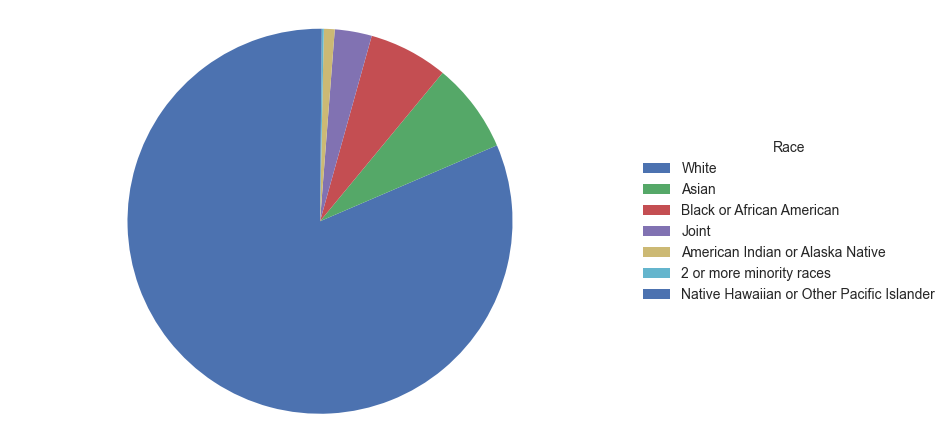

In [11]:
counts = df_pie1['derived_race'].value_counts()
labels = counts.index

#Create figure and axes
fig, ax = plt.subplots()

#Pie chart
patches, texts = ax.pie(counts, startangle = 90)
ax.legend(patches, labels, title = "Race", loc = "center left", bbox_to_anchor = (1, 0, 0.5, 1))
ax.axis('equal') 

plt.show()

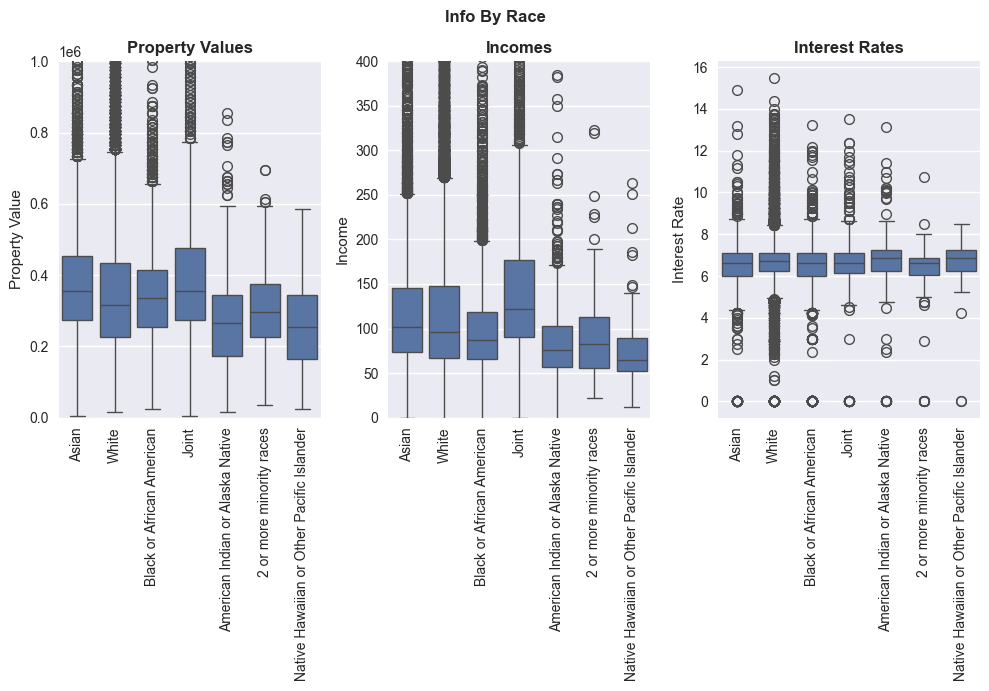

In [12]:
#Info by Race
plt.figure(figsize = (10, 7))
plt.suptitle("Info By Race", fontweight = 'bold')

#1st
plt.subplot(131)
sns.boxplot(x = 'derived_race', y = 'property_value', data = df_pie1)
plt.title("Property Values", fontweight = 'bold')
plt.xlabel('')
plt.ylabel('Property Value')
plt.ylim((0, 1000000))
x = plt.xticks(rotation = 90)

#2nd
plt.subplot(132)
sns.boxplot(x = 'derived_race', y = 'income', data = df_pie1)
plt.title("Incomes", fontweight = 'bold')
plt.xlabel('')
plt.ylabel('Income')
plt.ylim((0, 400))
x = plt.xticks(rotation = 90)

#3rd
plt.subplot(133)
sns.boxplot(x = 'derived_race', y = 'interest_rate', data = df_pie1)
plt.title("Interest Rates", fontweight = 'bold')
plt.xlabel('')
plt.ylabel('Interest Rate')
x = plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()

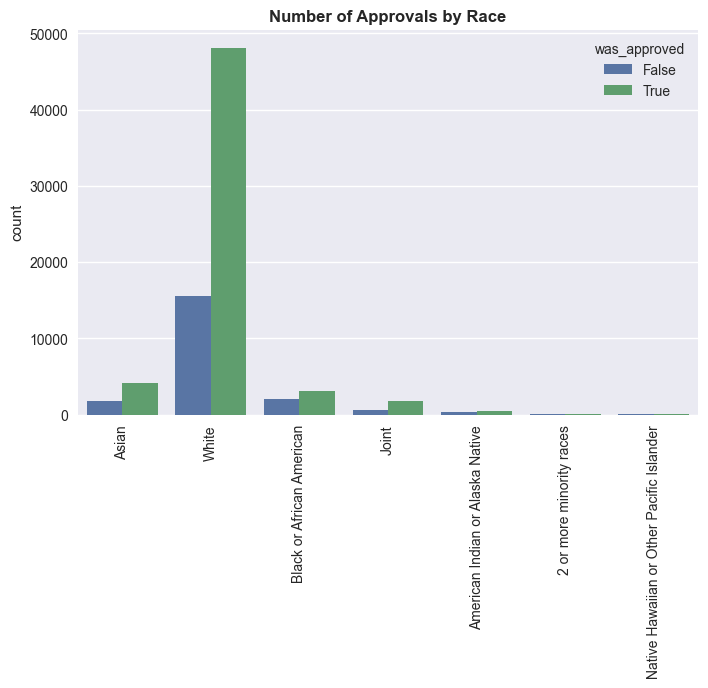

In [13]:
#
plt.figure(figsize = (8, 5))
sns.countplot(x = "derived_race", hue = "was_approved", data = df_pie1)
plt.title("Number of Approvals by Race", fontweight = 'bold')
plt.xlabel('')
x = plt.xticks(rotation = 90)
plt.show()